In [1]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
import sys
import os
import mmap

In [3]:
from multiprocessing import shared_memory

sys.path.append("..")
import extract_memory
layout=extract_memory.get_header_format('../memory_layout.h')
NAME='NW_SRC0_HDR'
shmem_main = shared_memory.SharedMemory(name=NAME)

layout_log=extract_memory.get_header_format('../layout_log.h')
NAME='NW_LOG'
#shm_log = shared_memory.SharedMemory(name=NAME, size=1024*1024)

layoutb=extract_memory.get_header_format('../layout_boxes.h')
buf_boxes=shmem_boxes.buf
#test

In [4]:
import psutil
print( psutil.cpu_times() )
#cputimes(user=237.75, system=402.5625, idle=7884.859375, interrupt=2.421875, dpc=3.71875)
psutil.virtual_memory()

scputimes(user=374211.48437499994, system=195036.53124999255, idle=43158524.1875, interrupt=5447.328125, dpc=19952.078125)


svmem(total=34204635136, available=19924951040, percent=41.7, used=14279684096, free=19924951040)

In [6]:
nptypes={'double':np.float64, 'uint16_t':np.uint16,'uint8_t':np.uint8}
def shmem_item(shmem1,layout,varname):
    item_info=layout[1][varname]
    data=np.frombuffer(shmem1, dtype=nptypes[item_info['type']],
                       count=item_info['num_elements'], offset=item_info['bytenum_current'])
    if len(data)==1:
        data=data[0]
    return data

def shmem_write(shmem1,layout,varname,data):
    item_info=layout[1][varname]
    bytez =np.array(data, dtype=nptypes[item_info['type']]).tobytes()   
    offset=item_info['bytenum_current']
    shmem1[offset : offset + len(bytez)] = bytez

class NW_shmem:
    def __init__(self,mem,layout):
        self.mem = mem
        self.layout = layout

    def item(self,name):
        return shmem_item(self.mem, self.layout, name)

    def write(self,name,data):
        return shmem_write(self.mem, self.layout, name, data)

    def get_fields(self):
        return list( self.layout[1].keys() )
        
# New way:
boxmem = NW_shmem(buf_boxes,layoutb)
num_boxes=boxmem.item("num_boxes")


# OLD WAY:

centroid_x=shmem_item( buf_boxes, layoutb, 'centroid_x')[0:num_boxes]
centroid_y=shmem_item( buf_boxes, layoutb, 'centroid_y')[0:num_boxes]
reference_x=shmem_item( buf_boxes, layoutb, 'reference_x')[0:num_boxes]
reference_y=shmem_item( buf_boxes, layoutb, 'reference_y')[0:num_boxes]


mem0 = NW_shmem(shmem_main.buf,layout)

print( num_boxes, centroid_x[0],  centroid_y[0] )

333 474.0714285714286 255.00348432055748


In [17]:
mem0.item("mode")

NameError: name 'mem0' is not defined

In [7]:
# START HERE to RELOAD
num_boxes=shmem_item( buf_boxes, layoutb, 'num_boxes')

Z_TERMS = 65

# Make sure to do "save centroids+Zernikes from nextwave UI to save these files:"
mirs=np.loadtxt("../mirror_voltages.txt")
infi=np.load('../influ.npy')
zterms_full=np.load("../zterms_full.npy")
zt_inv2 = pinv(zterms_full[0:Z_TERMS] )

#inf_full = np.loadtxt(
#    "c:/MiniWave/MiniWaveConfiguration/InfluenceMatrix_ALPAO_7.5mm_new.txt")

inf_full = np.load("../infl_reduced.npy")

In [8]:
inf_full.shape, infi.shape

((97, 666), (666, 97))

In [9]:
# Don't use... Use above one to load the reduced
if False:
    sys.path.append("c:/code/nextwave")
    import functions_grid
    import zernike_functions
    nvalid_boxes = boxmem.item('pupil_radius_um')/boxmem.item('box_um')*1000
    valid_indices=functions_grid.find_indices(inf_full, nvalid_boxes)
    print( len(valid_indices) )
    
    inf_full = inf_full[:,valid_indices]

In [10]:
import zernike_functions

In [11]:
%load_ext autoreload
%autoreload 2

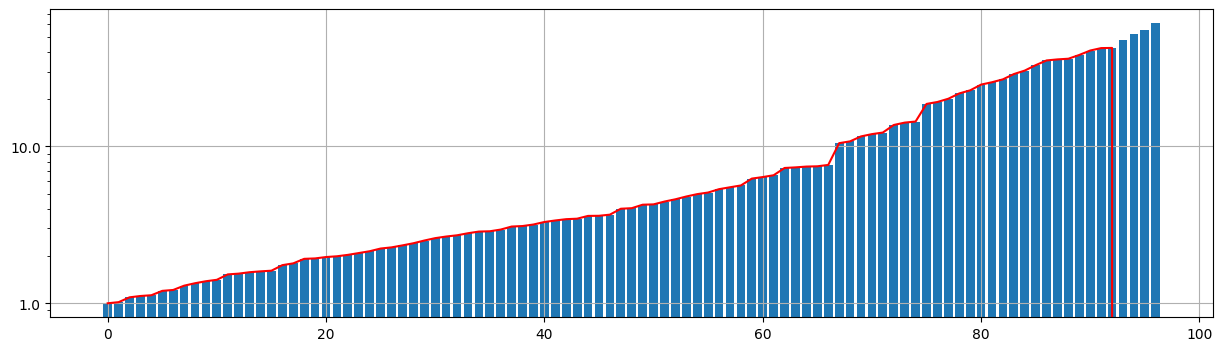

In [12]:
DESIRED_MODES=93

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter()
formatter.set_scientific(False) # Example: disable scientific notation
formatter.set_useOffset(False) # Example: disable offset

#if len(self.acts_outside)>0:
#    self.influence[self.acts_outside,:] = 0 # Zero them out, if any
U, s, V = np.linalg.svd(inf_full, full_matrices=True)
s_recip = 1/s
plt.figure(figsize=(15,4))
plt.bar(np.arange(len(s_recip)), s_recip/s_recip[0] )
plt.semilogy()
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()

if DESIRED_MODES < len(s):
    s_recip[DESIRED_MODES:] = 0
    
s_recip[ s<1e-10 ] = 0 # Set any tinies (or 0) to zero

influence_inv = ( (U * s_recip) @ V[0:97,:] ).T
#print( max_boxes, len(valid_boxes), self.influence.shape, s.max(), valid_boxes[0:10], RR.shape )

plt.plot( s_recip/s_recip[0], 'r-')

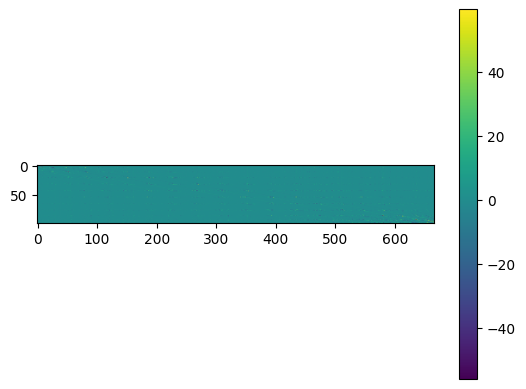

In [176]:
plt.imshow( influence_inv.T ); plt.colorbar()

In [733]:
influence_inv.max(), influence_inv.min()

(np.float64(60.87804382639833), np.float64(-62.23471313382029))

In [552]:
np.abs( influence_inv ).min()

np.float64(3.0357188533701357e-06)

In [553]:
np.abs( influence_inv ).max()

np.float64(62.23471313382029)

In [554]:
#influence_inv.shape, slope_reshape.shape

In [ ]:
GAIN=1.0

WRITE_MIRRORS=False
ZERO_FIRST=True
DO_PLOT=False
OVERRIDE_MEASURED=False

if ZERO_FIRST:
    boxmem.write("mirror_voltages",mirs_new*0)
    shmir=np.zeros(97)
    time.sleep(0.25)
else:
    shmir =shmem_item( buf_boxes, layoutb, 'mirror_voltages')[0:97]

if DO_PLOT:
    print( shmir.max())

centroid_x=boxmem.item('centroid_x')[0:num_boxes]
centroid_y=boxmem.item('centroid_y')[0:num_boxes]
reference_x=boxmem.item('reference_x')[0:num_boxes]
reference_y=boxmem.item('reference_y')[0:num_boxes]

# This matches what is shown on the screen
spot_displace_x =   centroid_x - reference_x  
spot_displace_y =   centroid_y - reference_y

if DO_PLOT:
    MULT=5
    plt.plot( (reference_x,reference_x+spot_displace_x*MULT),
             (reference_y,reference_y+spot_displace_y*MULT), 'g-' )
    plt.plot( reference_x,reference_y, 'k.' )
    plt.gca().invert_yaxis()
    plt.gca().axis('equal')

spot_displace_y -= spot_displace_y.mean()
spot_displace_x -= spot_displace_x.mean()
spot_displace_y = -spot_displace_y

slope = np.concatenate( (spot_displace_y, spot_displace_x)) * (boxmem.item("pixel_um")) /( boxmem.item("focal_um")/1000)

if OVERRIDE_MEASURED:
    # THIS WILL OVERRIDE the CURRENT readings with theoretical estimate from matrix inverse of best Mirror setting
    slope = -slopes_system.copy() #slope_uncor

coeff=np.matmul(zterms_full,slope)

#zernikes=coeff #[zernike_functions.CVS_to_OSA_map[0:len(coeff)]] # Return value will is OSA
zernikes=coeff[zernike_functions.CVS_to_OSA_map[0:len(coeff)]] # Return value will is OSA

#zernikes=zernikes_model_eye_base;
zernikes[3] += 0.0 #/ ((boxmem.item("pixel_um")) /( boxmem.item("focal_um") ) * 1000)

slopes_est2 =np.matmul( zt_inv2, zernikes[zernike_functions.OSA_to_CVS_map[0:Z_TERMS]] )
#slopes_est2 =np.matmul( zt_inv2, zernikes )
slopes_est=slopes_est2

if DO_PLOT:
    plt.figure(figsize=(15,2))
    plt.bar( np.arange(len(zernikes[1:])), zernikes[1:] )
    
    plt.figure(figsize=(15,4))
    plt.plot( slopes_est2, label='full' )
    plt.plot( slope, '.', label='orig' )
    plt.plot( slopes_est, ls='--', label='partial' )
    plt.xlim(0-5, len(slope)+5 )
    plt.legend()
    
    plt.figure(figsize=(15,4))
    #plt.plot( mirs, 'o-' )
    #plt.plot( shmir, 's-' )
    plt.grid()

halfway = slopes_est.shape[0]//2
slope_reshape = np.vstack( (slopes_est2[halfway:],slopes_est2[:halfway]) ).T.flatten()
mirs_new = np.matmul(influence_inv.T, slope_reshape/1000.0)

if DO_PLOT:
    plt.plot( -mirs_new*GAIN, 'r--' )

if (WRITE_MIRRORS):
    mirs_now=boxmem.item("mirror_voltages")[0:97]
    boxmem.write("mirror_voltages",-mirs_new*GAIN+mirs_now)
    mem0.write("mode",[mem0.item("mode") | 0x20] )

In [ ]:
mirs_now=boxmem.item("mirror_voltages")[0:97]
boxmem.write("mirror_voltages",-mirs_new*GAIN+mirs_now)
mem0.write("mode",[mem0.item("mode") | 0x20] )

In [ ]:
mem0.item("mode")

In [ ]:
mem0.mem.readonly

In [ ]:
plt.plot( -mirs_new*GAIN - shmir )

In [ ]:
plt.figure(figsize=(15,4))
slope_reshape = np.vstack( (slopes_est2[halfway:],slopes_est2[:halfway]) ).T.flatten()
slope_reshape = np.vstack( (slope[halfway:],slope[:halfway]) ).T.flatten()
plt.plot( slope_reshape/1000.0, label='est')

shlop=shmem_item( buf_boxes, layoutb, 'box_x_normalized')[0:num_boxes*2]
plt.plot( shlop, label='shmem')

plt.xlim(100,300)
plt.legend()

In [53]:
zernikes_model_eye_base = zernikes.copy()

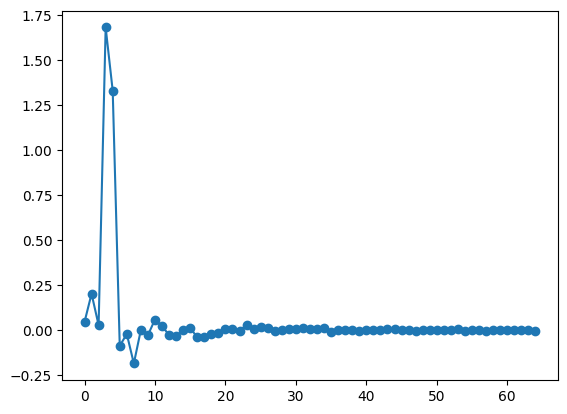

In [52]:
plt.plot( zernikes, 'o-' )

In [13]:
# Get Kaitlyn's Zs
import pandas

df_k = pandas.read_csv('./dataset.csv')
df_k

Z_k = np.array( df_k.iloc[0,6:].to_numpy(), dtype='float64' )
Z_k_ho = Z_k.copy()
Z_k_ho[0:5]=0

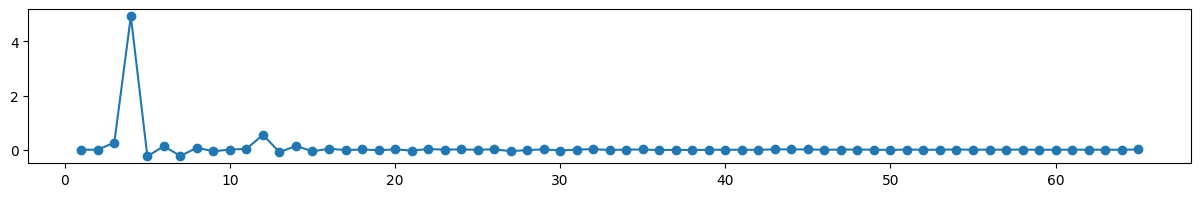

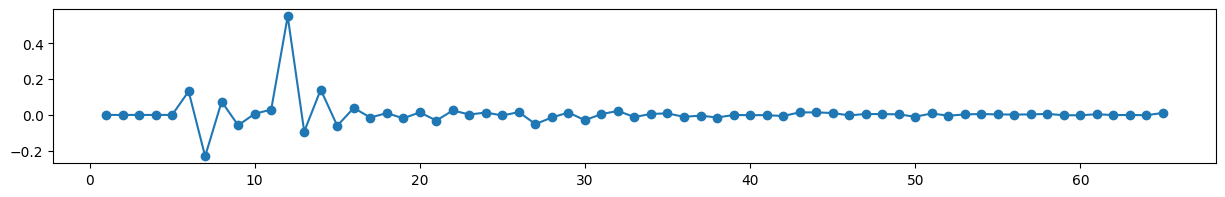

In [14]:
plt.figure(figsize=(15,2))
plt.plot( np.arange(len(Z_k))+1, Z_k, 'o-' )

plt.figure(figsize=(15,2))
plt.plot( np.arange(len(Z_k_ho))+1, Z_k_ho, 'o-' )

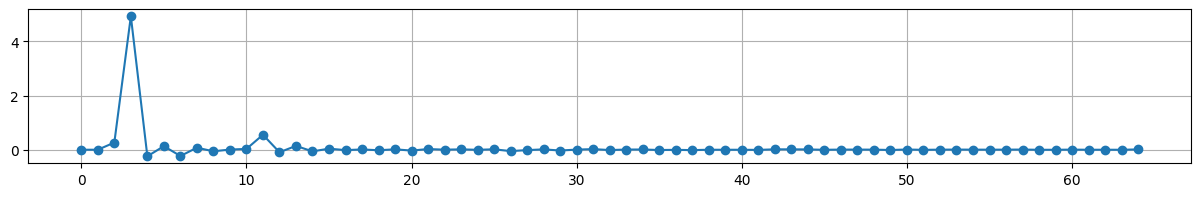

In [15]:
plt.figure(figsize=(15,2))
plt.plot( np.arange(len(Z_k)), Z_k, 'o-' )
plt.grid()

In [16]:
# Get new "best mirror" / flat wavefront  / "
mirs_model_best=boxmem.item("mirror_voltages")[0:97].copy()
slopes_desired = np.matmul(mirs_model_best,inf_full) / (boxmem.item("pixel_um")/boxmem.item("focal_um") )
slopes_system = slopes_desired.copy()  #np.vstack( (slopes_desired[halfway:],slopes_desired[:halfway]) ).T.flatten()*1000
halfway = len(slopes_system)//2
slopes_system[:halfway] = slopes_desired[1::2]
slopes_system[halfway:] = slopes_desired[0::2]

In [17]:
inf_full.shape

(97, 666)

In [18]:
#plt.plot ( slopes_system, slope_uncor, 'o')

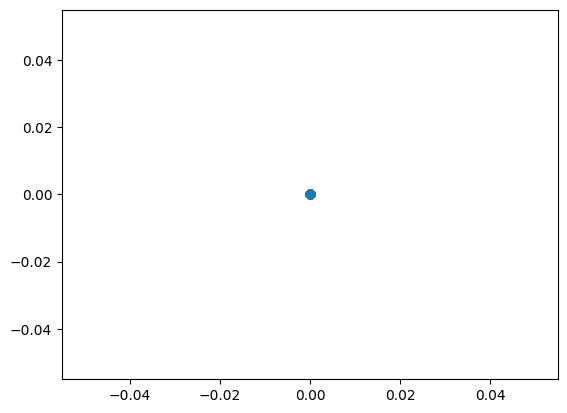

In [19]:
mirs_now=boxmem.item("mirror_voltages")[0:97]
plt.plot( mirs_now, mirs_model_best, 'o' )

In [196]:
slope_uncor2 = slope.copy()

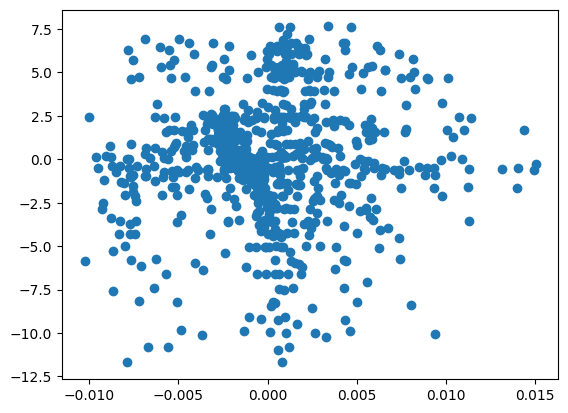

In [199]:
plt.plot( slopes_desired, slope_uncor, 'o' )

In [252]:
(boxmem.item("pixel_um")) /( boxmem.item("focal_um")/1000)

np.float64(0.9821428571428572)

In [329]:
(boxmem.item("pixel_um")) /( boxmem.item("focal_um") ) * 1000

np.float64(0.9821428571428572)

In [20]:
nptypes={'double':np.float64, 'uint16_t':np.uint16,'uint8_t':np.uint8,  'uint64_t':np.uint64}
def shmem_item(shmem1,layout,varname,offset2=0):
    item_info=layout[1][varname]
    data=np.frombuffer(shmem1, dtype=nptypes[item_info['type']],
                       count=item_info['num_elements'], offset=item_info['bytenum_current']+offset2)
    if len(data)==1:
        data=data[0]
    return data

def shmem_write(shmem1,layout,varname,data):
    item_info=layout[1][varname]
    bytez =np.array(data, dtype=nptypes[item_info['type']]).tobytes()   
    offset=item_info['bytenum_current']
    shmem1[offset : offset + len(bytez)] = bytez

class NW_shmem:
    def __init__(self,mem,layout):
        self.mem = mem
        self.layout = layout

    def item(self,name,offset2=0):
        return shmem_item(self.mem, self.layout, name, offset2=offset2)

    def write(self,name,data):
        return shmem_write(self.mem, self.layout, name, data)

    def get_fields(self):
        return list( self.layout[1].keys() )
        
        
shm_log = shared_memory.SharedMemory(name="NW_LOG")
log0 = NW_shmem( shm_log.buf, layout_log)
nframe=0
im1=log0.item("im",4231194*nframe)
im1=im1[0:1024*1024].reshape( (1024, 1024) )

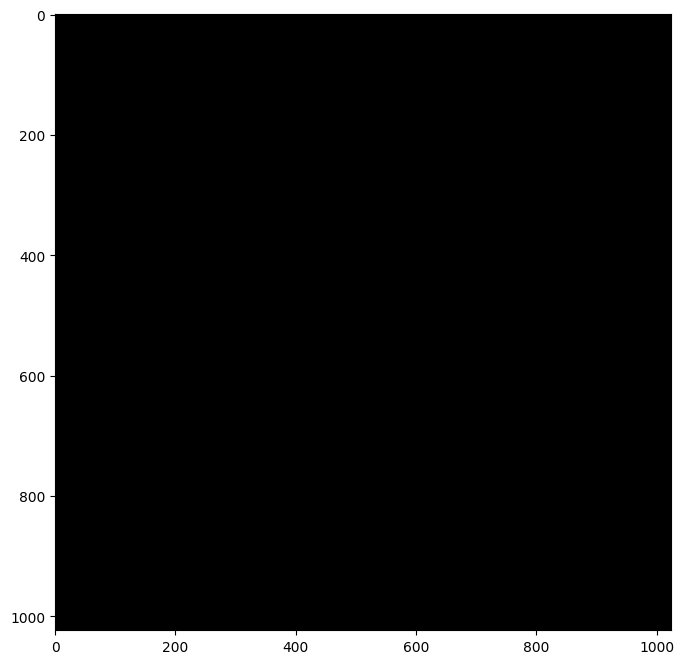

In [21]:
# UNSCANNING
im1=log0.item("im",4231194*nframe)
n=2
im1=im1[1024*1024*n:1024*1024*(n+1)].reshape( (1024, 1024) )

plt.figure(figsize=(8,8))
plt.imshow( im1, cmap='bone')

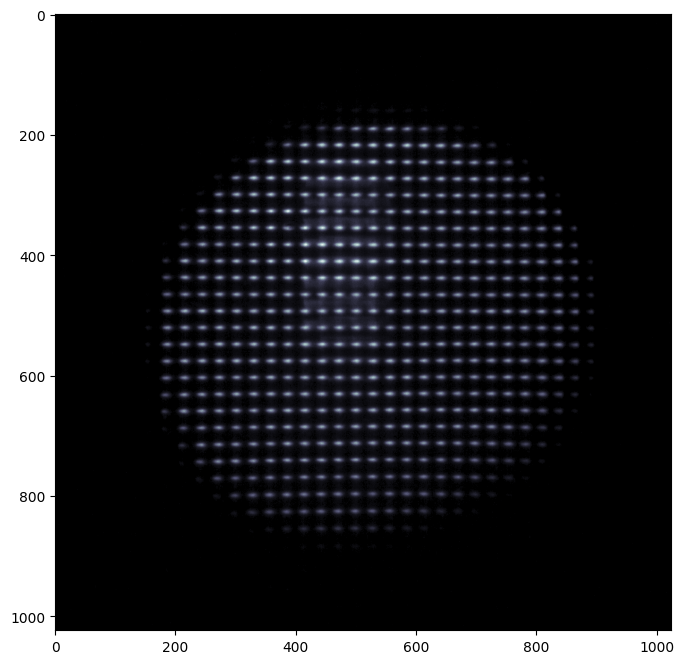

In [376]:
#Scanning
im1=log0.item("im",4231194*nframe)
im1=im1[0:1024*1024].reshape( (1024, 1024) )

plt.figure(figsize=(8,8))
plt.imshow( im1, cmap='bone')

In [86]:
im1=log0.item("im",4231194*nframe)
im1=im1[0:1024*1024].reshape( (1024, 1024) )

plt.figure(figsize=(8,8))
plt.imshow( im1, cmap='bone')

NameError: name 'log0' is not defined

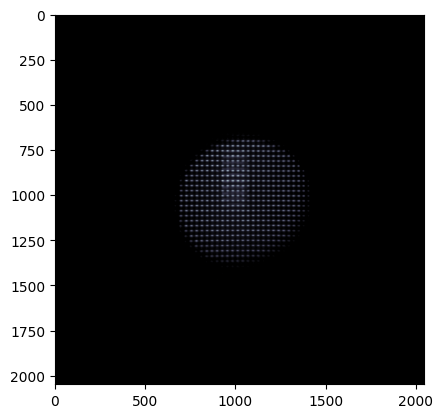

In [378]:
# On the entire sensor
im_wfs = np.zeros ((2048,2048))
im_wfs[512:512+1024,512:512+1024 ] = im1.copy()
plt.imshow( im_wfs, cmap='bone')

In [22]:
def do_ao1(GAIN=1.0,WRITE_MIRRORS=False,ZERO_FIRST=True,DO_PLOT=False,OVERRIDE_MEASURED=False,zerns_new=np.zeros(65),thresh=0.4):
    mirs_new=np.zeros(97)
    if ZERO_FIRST:
        boxmem.write("mirror_voltages",mirs_new*0)
        shmir=np.zeros(97)
        time.sleep(0.25)
    else:
        shmir =shmem_item( buf_boxes, layoutb, 'mirror_voltages')[0:97]
    
    if DO_PLOT:
        print( shmir.max())
    
    centroid_x=boxmem.item('centroid_x')[0:num_boxes]
    centroid_y=boxmem.item('centroid_y')[0:num_boxes]
    reference_x=boxmem.item('reference_x')[0:num_boxes]
    reference_y=boxmem.item('reference_y')[0:num_boxes]
    
    # This matches what is shown on the screen
    spot_displace_x =   centroid_x - reference_x  
    spot_displace_y =   centroid_y - reference_y
    
    if DO_PLOT:
        MULT=5
        plt.plot( (reference_x,reference_x+spot_displace_x*MULT),
                 (reference_y,reference_y+spot_displace_y*MULT), 'g-' )
        plt.plot( reference_x,reference_y, 'k.' )
        plt.gca().invert_yaxis()
        plt.gca().axis('equal')
    
    spot_displace_y -= spot_displace_y.mean()
    spot_displace_x -= spot_displace_x.mean()
    spot_displace_y = -spot_displace_y

    metric=boxmem.item("centroid_valid")[0:num_boxes]/200.0
    valids = (metric >= thresh)
    
    slope = np.concatenate( (spot_displace_y[valids], spot_displace_x[valids])) * (boxmem.item("pixel_um")) /( boxmem.item("focal_um")/1000)
    
    if OVERRIDE_MEASURED:
        # THIS WILL OVERRIDE the CURRENT readings with theoretical estimate from matrix inverse of best Mirror setting
        slope = -slopes_system.copy() #slope_uncor
        valids = (metric>=0) # Get everything

    print( '%d/%d' % (np.sum(valids), len(valids ) ), end=' ' )
    valid_stacked = np.concatenate( (valids, valids) )
    
    coeff=np.matmul(zterms_full[:,valid_stacked],slope)
    
    #zernikes=coeff #[zernike_functions.CVS_to_OSA_map[0:len(coeff)]] # Return value will is OSA
    zernikes=coeff[zernike_functions.CVS_to_OSA_map[0:len(coeff)]] # Return value will is OSA
    
    # Remove any tip/tilt
    zernikes[0] = 0
    zernikes[1] = 0
    zernikes += zerns_new #/ ((boxmem.item("pixel_um")) /( boxmem.item("focal_um") ) * 1000)
    
    slopes_est2 =np.matmul( zt_inv2, zernikes[zernike_functions.OSA_to_CVS_map[0:Z_TERMS]] )
    #slopes_est2 =np.matmul( zt_inv2, zernikes )
    slopes_est=slopes_est2
    
    if DO_PLOT:
        plt.figure(figsize=(15,2))
        plt.bar( np.arange(len(zernikes[1:])), zernikes[1:] )
        
        plt.figure(figsize=(15,4))
        plt.plot( slopes_est2, label='full' )
        plt.plot( slope, '.', label='orig' )
        plt.plot( slopes_est, ls='--', label='partial' )
        plt.xlim(0-5, len(slope)+5 )
        plt.legend()
        
        plt.figure(figsize=(15,4))
        #plt.plot( mirs, 'o-' )
        #plt.plot( shmir, 's-' )
        plt.grid()
    
    halfway = slopes_est.shape[0]//2
    slope_reshape = np.vstack( (slopes_est2[halfway:],slopes_est2[:halfway]) ).T.flatten()
    mirs_new = np.matmul(influence_inv.T, slope_reshape/1000.0)
    
    if DO_PLOT:
        plt.plot( -mirs_new*GAIN, 'r--' )
    
    if (WRITE_MIRRORS):
        mirs_now=boxmem.item("mirror_voltages")[0:97]
        boxmem.write("mirror_voltages",-mirs_new*GAIN+mirs_now)
        mem0.write("mode",[mem0.item("mode") | 0x20] )

In [23]:
((boxmem.item("pixel_um")) /( boxmem.item("focal_um") ) * 1000)

np.float64(0.9821428571428572)

In [75]:
# One giant leap to KAitlyn's Zerns
GAIN=1.0
WRITE_MIRRORS=True
ZERO_FIRST=True
DO_PLOT=False
OVERRIDE_MEASURED=True

print( Z_k[2:5] )
Z_new=np.zeros(65)
Z_new[2] = -Z_k[2] -0.0
Z_new[3] = -Z_k[3] + 1.0*0
Z_new[4] = -Z_k[4] + 0.0
Z_new[11]=-0.5*1
#Z_new = -Z_k
do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED,zerns_new= 
       Z_new)
print()
print( Z_new[2:5] )

[ 0.264171  4.924246 -0.241692]
333/333 
[-0.264171 -4.924246  0.241692]


In [ ]:
# One giant leap to Model Eye
GAIN=1.0
WRITE_MIRRORS=True
ZERO_FIRST=True
DO_PLOT=False
OVERRIDE_MEASURED=True

Z_new=np.zeros(65)
Z_new[2:5]= -np.array( [0, 1,-1.1] )
# Z_new[11]=0.55
#Z_new = -Z_k
do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED,zerns_new= 
       Z_new)

In [749]:
print( Z_k[2:5] )

[ 0.264171  4.924246 -0.241692]


In [686]:
# One giant leap
GAIN=1.0
WRITE_MIRRORS=True
ZERO_FIRST=True
DO_PLOT=False
OVERRIDE_MEASURED=True

do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED)

333/333 

In [661]:
# One small step
GAIN=1.0
WRITE_MIRRORS=True
ZERO_FIRST=False
DO_PLOT=False
OVERRIDE_MEASURED=False

do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED,thresh=0.5)

328/333 

In [83]:
# Many little steps
GAIN=0.5
WRITE_MIRRORS=True
ZERO_FIRST=False
DO_PLOT=False
OVERRIDE_MEASURED=False

zerns_new=np.zeros(65)
#zerns_new[3] = 1.0
while True:
#if True:
    do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED, zerns_new,thresh=0.2)
    time.sleep(0.5)

0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 

KeyboardInterrupt: 

In [63]:
# Through focus
GAIN=1.0
WRITE_MIRRORS=True
ZERO_FIRST=False
DO_PLOT=False
OVERRIDE_MEASURED=False

do_ao1(GAIN,WRITE_MIRRORS,1,DO_PLOT,OVERRIDE_MEASURED)
time.sleep(0.5)

zerns_new=np.zeros(65)
for defocus in np.linspace(0,2.0,11):
    zerns_new[3] = defocus
    do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED, zerns_new)
    time.sleep(0.5)

0/333 0/333 0/333 0/333 0/333 0/333 0/333 

KeyboardInterrupt: 

In [76]:
# Alternate
GAIN=1.0
WRITE_MIRRORS=True
ZERO_FIRST=False # I think True is better
DO_PLOT=False
OVERRIDE_MEASURED=False

do_ao1(GAIN,WRITE_MIRRORS,1,DO_PLOT,OVERRIDE_MEASURED)
time.sleep(0.5)

while True:
    for defocus in [-1,0]:
        zerns_new[3] = defocus
        do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED, zerns_new)
        time.sleep(0.5)

0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 

KeyboardInterrupt: 

In [474]:
metric=boxmem.item("centroid_valid")[0:num_boxes]

(array([ 1.,  2.,  2.,  4.,  3.,  3.,  3.,  4.,  0.,  0.,  3.,  2.,  4.,
         1.,  2.,  0.,  4.,  2.,  1.,  3., 19., 22., 16., 23., 33., 32.,
        47., 77., 48., 28., 12.]),
 array([0.05      , 0.06887097, 0.08774194, 0.1066129 , 0.12548387,
        0.14435484, 0.16322581, 0.18209677, 0.20096774, 0.21983871,
        0.23870968, 0.25758065, 0.27645161, 0.29532258, 0.31419355,
        0.33306452, 0.35193548, 0.37080645, 0.38967742, 0.40854839,
        0.42741935, 0.44629032, 0.46516129, 0.48403226, 0.50290323,
        0.52177419, 0.54064516, 0.55951613, 0.5783871 , 0.59725806,
        0.61612903, 0.635     ]),
 <BarContainer object of 31 artists>)

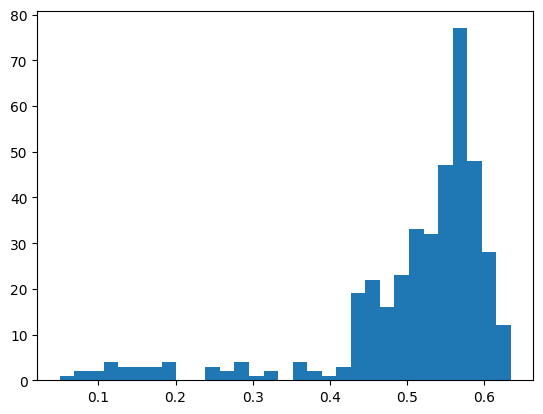

In [506]:
plt.hist( metric / 200.0, bins=31)

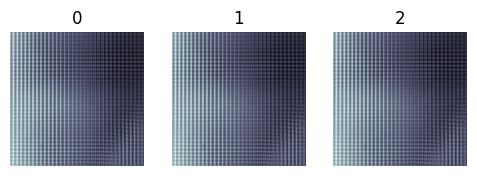

In [169]:
#Scanning
nframe=0
im1=log0.item("im",4231194*nframe)
im1=im1[0:1024*1024].reshape( (1024, 1024) )

plt.figure(figsize=(8,8))
for nframe in np.arange(0,3):
    plt.subplot(4,4,nframe+1)
    plt.imshow( im1, cmap='bone')
    plt.axis('off')
    plt.title(nframe)
    np.save("kaitlyn_good_spots_%d"%nframe,im1)

In [128]:
import joystickapi
import msvcrt
import time

print("start")

num = joystickapi.joyGetNumDevs()
ret, caps, startinfo = False, None, None
for id in range(num):
    ret, caps = joystickapi.joyGetDevCaps(id)
    if ret:
        print("gamepad detected: " + caps.szPname)
        ret, startinfo = joystickapi.joyGetPosEx(id)
        break
else:
    print("no gamepad detected")

run = ret
value = 2
while run:
    time.sleep(0.50)
    if msvcrt.kbhit() and msvcrt.getch() == chr(27).encode(): # detect ESC
        run = False

    ret, info = joystickapi.joyGetPosEx(id)
    if ret:
        btns = [(1 << i) & info.dwButtons != 0 for i in range(caps.wNumButtons)]
        axisXYZ = [info.dwXpos-startinfo.dwXpos, info.dwYpos-startinfo.dwYpos, info.dwZpos-startinfo.dwZpos]
        axisRUV = [info.dwRpos-startinfo.dwRpos, info.dwUpos-startinfo.dwUpos, info.dwVpos-startinfo.dwVpos]
        if info.dwButtons:
            if btns[1]:
                break
        #        time.sleep(0.25)
                # One giant leap to KAitlyn's Zerns
        #        GAIN=1.0
        #        WRITE_MIRRORS=True
        #        ZERO_FIRST=True
        #        DO_PLOT=False
        #        OVERRIDE_MEASURED=True
                
                #Z_new=np.zeros(65)
               # Z_new[2:5]=-Z_k[2:5]
                # Z_new[11]=0.55
                #Z_new = -Z_k
                #do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED,zerns_new= 
                #       Z_new)
                

        #if any([abs(v) > 10 for v in axisXYZ]):
        
            #print("axis:", axisXYZ)
        if any([abs(v) > 50 for v in axisRUV]):
            delta = float(axisRUV[0])/32769 # Scale to -1 to +1
            value = delta * 8   # Now it's -8 to 8... (um)
            #print("roation axis:", value)

            # One giant leap to KAitlyn's Zerns
            GAIN=1.0
            WRITE_MIRRORS=True
            ZERO_FIRST=True
            DO_PLOT=False
            OVERRIDE_MEASURED=True
                
            Z_new=np.zeros(65)
            Z_new[2]=-Z_k[2]
            Z_new[3]=-value
            Z_new[4]=-Z_k[4]
            #Z_new[11]=0.55
            #Z_new = -Z_k
            do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED,zerns_new= 
                   Z_new)
            print(value,end= ' ')
print('\n', value,end= ' ')            
print("end")


start
gamepad detected: Microsoft PC-joystick driver
333/333 0.41038786658122006 333/333 4.697610546553145 333/333 4.663431902102597 333/333 4.663431902102597 333/333 4.668314565595533 333/333 4.668314565595533 333/333 4.673197229088467 333/333 4.678079892581403 333/333 5.200524886325491 333/333 5.420244743507584 333/333 5.635081937196741 
 5.635081937196741 end
